In [ ]:
import matplotlib.pyplot as plt
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d

# For optimization/visualizations
import optuna
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

from tqdm import tqdm

In [ ]:
### SET UP FOR A THREE LEVEL SYSTEM
ground = Qobj([[1],[0],[0]])  
storage = Qobj([[0],[1],[0]]) 
excited = Qobj([[0],[0],[1]]) 

sigma_ee = Qobj([[0,0,0],[0,0,0],[0,0,1]])  # |e><e| 

sigma_ge = Qobj([[0,0,0],[0,0,0],[1,0,0]])  # |e><g| (transition from g to e)
sigma_eg = Qobj([[0,0,1],[0,0,0],[0,0,0]])  # |g><e| (transition from e to g)

sigma_se = Qobj([[0,0,0],[0,0,0],[0,1,0]])  # |e><s| (transition from s to e)
sigma_es = Qobj([[0,0,0],[0,0,1],[0,0,0]])  # |s><e| (transition from e to s)

sigma_gs = Qobj([[0,0,0],[1,0,0],[0,0,0]])  # |s><g| (transition from g to s)
sigma_sg = Qobj([[0,1,0],[0,0,0],[0,0,0]])  # |g><s| (transition from s to g)

In [ ]:
def three_level_simulation(a_factor, C, gamma, Delta, T, g_se, g_ge, alpha_in_func):
    N = 5000  # number of time steps
    time = np.linspace(0, T, N)
    alpha_in = alpha_in_func  
    alpha = alpha_in(time)
    
    # Prefactors
    a = -a_factor*(gamma*(1/C+1) - 1j*Delta) / np.sqrt(2*gamma*(1/C+1))
    c = gamma**2*(1/C+1)**2 + Delta**2
    
    # Compute b
    b = [0]
    for i in range(1, len(time)):
        integral_val = integrate.simps(abs(alpha[0:i])**2, time[0:i])
        if integral_val == 0:
            b.append(0)
        else:
            b.append(alpha[i] / np.sqrt(integral_val))
    b = np.array(b)
    
    # Function to get h(t, T)
    def get_h(beta_vals, idx, time):
        h_val = integrate.simps(np.abs(beta_vals[idx:])**2, time[idx:])
        return h_val
    
    beta_vals = np.array([0])
    for idx in range(len(time)-1):
        h = get_h(a*b, idx, time)
        beta_vals = np.append(beta_vals, a*b[idx]*np.exp(1j*Delta*h/c))
    
    def beta(t):
        if t == time[0]: return 0
        else: return np.interp(t, time, beta_vals)
    
    # Hamiltonian
    H_signal = sigma_ge + sigma_eg
    H_coupling = sigma_se
    H_coupling_dag = sigma_es
    H_detuning = sigma_ee
    
    def H_detuning_coeff(t, args):
        return Delta
    
    def H_signal_coeff(t, args):
        return g_ge * alpha_in(t)
    
    def H_coupling_coeff(t, args):
        return g_se * beta(t)
    
    def H_coupling_dag_coeff(t, args):
        return g_se * np.conjugate(beta(t))
    
    H = [[H_detuning, H_detuning_coeff], [H_signal, H_signal_coeff], [H_coupling, H_coupling_coeff], [H_coupling_dag, H_coupling_dag_coeff]]
    
    # Dissipation
    def col_coeff_eg(t, args):
        return -np.conjugate(g_ge)
    c_op_list = [[sigma_eg, col_coeff_eg], [sigma_eg, -1/C]]
    
    # Simulate
    psi0 = ground
    result = mesolve(H, psi0, time, c_op_list)
    
    # Extract results
    prob_g = []
    prob_s = []
    prob_e = []
    S = []
    for state in result.states:
        p_g, p_s, p_e = state[0][0], state[1][1], state[2][2]
        prob_g.append(p_g)
        prob_s.append(p_s)
        prob_e.append(p_e)
        S.append(expect(sigma_gs, state))
    
    return time, np.array(S), np.array(prob_s), np.array(prob_g), np.array(prob_e)

In [4]:
def plot_probs(time, prob_g, prob_e, prob_s, S):
    fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
    axs[0].plot(time, prob_g + prob_e + prob_s, color='red', label='Total')
    axs[0].plot(time, prob_g, color='blue', label='Ground')
    axs[0].set_ylabel('Probability')
    axs[0].set_title('Ground State Probability')
    axs[0].grid()
    axs[0].legend()

    axs[1].plot(time, prob_s, color='orange')
    axs[1].set_ylabel('Probability')
    axs[1].set_title('Storage State Probability')
    axs[1].grid()

    axs[2].plot(time, prob_e, color='green')
    axs[2].set_xlabel('Time')
    axs[2].set_ylabel('Probability')
    axs[2].set_title('Excited State Probability')
    axs[2].grid()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(time, abs(S), label='|S|')
    plt.plot(time, np.real(S), label='Re(S)')
    plt.plot(time, np.imag(S), label='Im(S)')
    plt.xlabel('Time')
    plt.ylabel('S')
    plt.legend()
    plt.grid()
    plt.show()

(0.7088723439378912-70.53456158585983j)
Final |s> probability: 0.0033685889114987155


C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


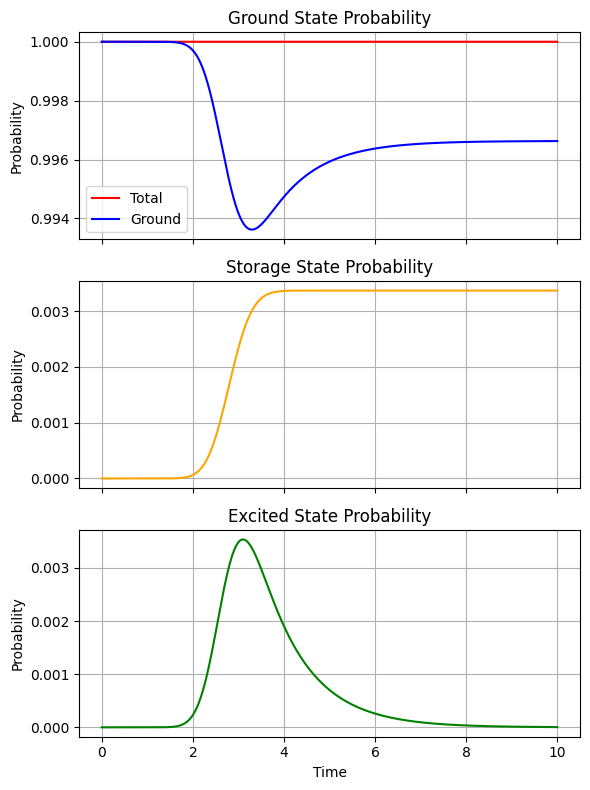

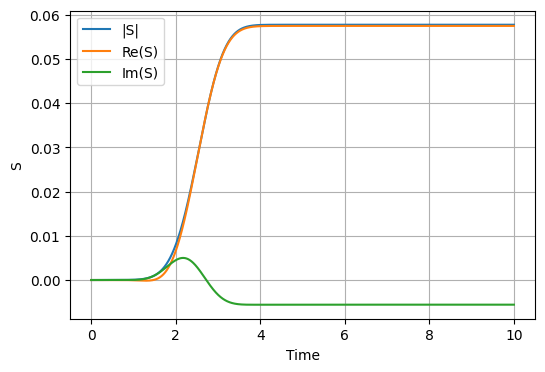

In [ ]:
# Example
C = 200
gamma = 1
Delta = 100
T = 10
g_se = 1
g_ge = 1
a_factor = 1

mu, sigma = 2.5, 0.5 # 2.5, 0.5 # defined for a Gaussian input pulse

# Returns area-normalized Gaussian
def gaussian(mu, sigma, t):
    return np.sqrt(1/(sigma*np.sqrt(np.pi))) * np.exp(-((t-mu)**2) / (2*sigma**2))

### INPUT COHERENT STATE
def alpha_in(t):
    amp = 0.1 # small amplitude
    return amp*(gaussian(mu, sigma, t)) 

time, S, prob_s, prob_g, prob_e = three_level_simulation(a_factor, C, gamma, Delta/C, T, g_se, g_ge, alpha_in)
print('Final |s> probability:', abs(prob_s[-1]))
plot_probs(time, prob_g, prob_e, prob_s, S)

# Summary 
$$ \hat{H} = g_{ge} \alpha(t)(\hat{\sigma}_{ge}+ \hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) + \Delta \hat{\sigma}_{ee}$$

$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -\frac{1}{C}{g_{ge}^*}\hat{\sigma}_{eg} \end{bmatrix} $$

$$\beta(t)= -\frac{\gamma(\frac{1}{C}+1)-i\Delta}{\sqrt{2\gamma(\frac{1}{C}+1)}} \cdot \frac{\alpha_{in}(t)}{\sqrt{\int_0^t{|\alpha_{in}(t)|^2 dt}}} \cdot
\text{exp} \left(\frac{i \Delta \cdot h(t, T)}{\gamma^2(\frac{1}{C}+1)^2+\Delta^2} \right) = a\times b \times \text{exp} (\frac{i \Delta \cdot h(t, T)}{c})$$

- In the Hamiltonian, should I divide $\Delta$ by C? Should $g_{ge}/g_{se}$ be some factor?

First, I will try to optimize over the existing parameters of $C, \Delta, \gamma$ with this optimal $\beta(t)$ by fixing all parameters except one, and then modifying the one parameter.

In [ ]:
C = 200
gamma = 1
Delta = 100
T = 10
g_se = 1 # np.sqrt(gamma*C*T)
g_ge = 1
a_factor = 1

C_vals =  np.linspace(0.01, 10, 50)
prob_s_vals = []
for C in C_vals:
    time, S, prob_s, prob_g, prob_e = three_level_simulation(C, gamma, Delta, T, g_se, g_ge, alpha_in)
    prob_s_vals.append(abs(prob_s[-1]))

Text(0.5, 0, 'Cooperativity (C)')

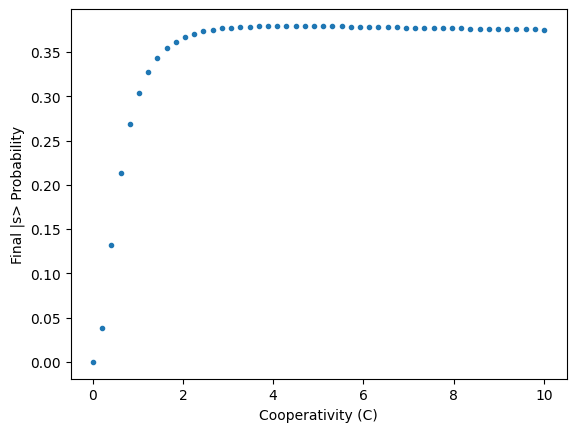

In [ ]:
plt.plot(C_vals, prob_s_vals, '.')
plt.ylabel('Final |s> Probability')
plt.xlabel('Cooperativity (C)')

In [ ]:
C = 200
gamma = 1
Delta = 100
T = 10
g_se = 1
g_ge = 1
a_factor = 1

detuning_vals =  np.linspace(0, 100, 50)
prob_s_vals = []
for Delta in detuning_vals:
    time, S, prob_s, prob_g, prob_e = three_level_simulation(C, gamma, Delta, T, g_se, g_ge, alpha_in)
    prob_s_vals.append(abs(prob_s[-1]))

Text(0.5, 0, 'Detuning')

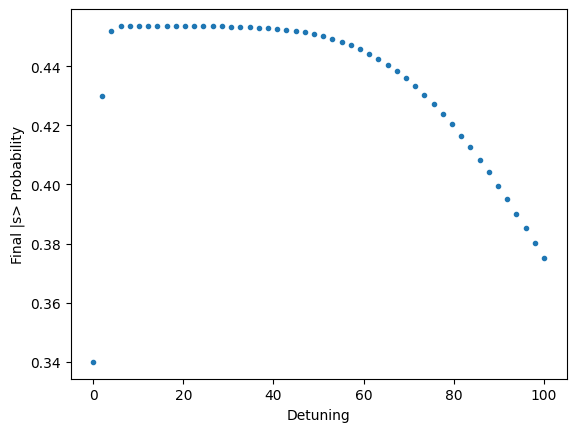

In [ ]:
plt.plot(detuning_vals, prob_s_vals, '.')
plt.ylabel('Final |s> Probability')
plt.xlabel('Detuning')

Text(0.5, 0, 'Factor (C)')

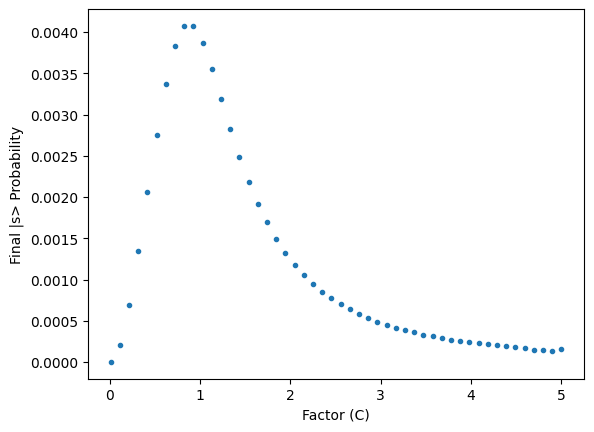

In [ ]:
a_factor_vals =  np.linspace(0.01, 5, 50)
prob_s_vals = []
for a_factor in a_factor_vals:
    time, S, prob_s, prob_g, prob_e = three_level_simulation(a_factor, C, gamma, Delta, T, g_se, g_ge, alpha_in)
    prob_s_vals.append(abs(prob_s[-1]))

plt.plot(a_factor_vals, prob_s_vals, '.')
plt.ylabel('Final |s> Probability')
plt.xlabel('Factor (C)')

0.8246938775510204


C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


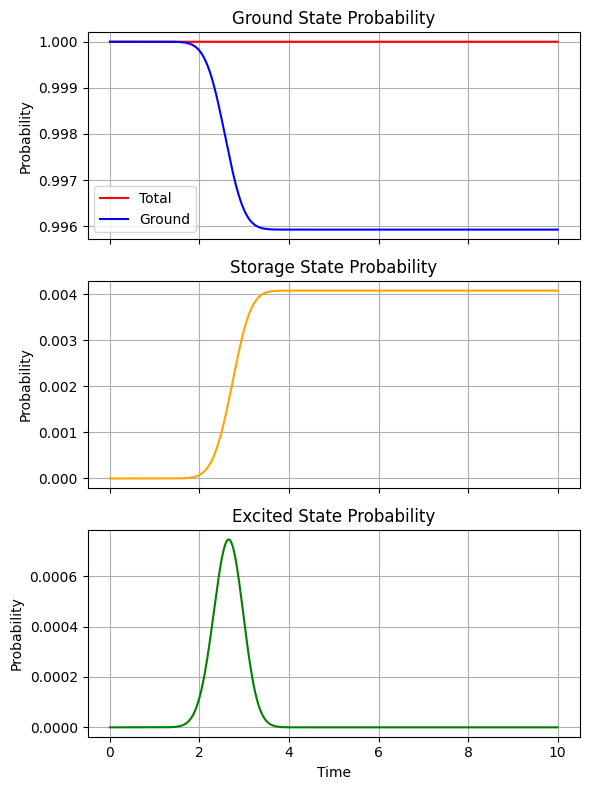

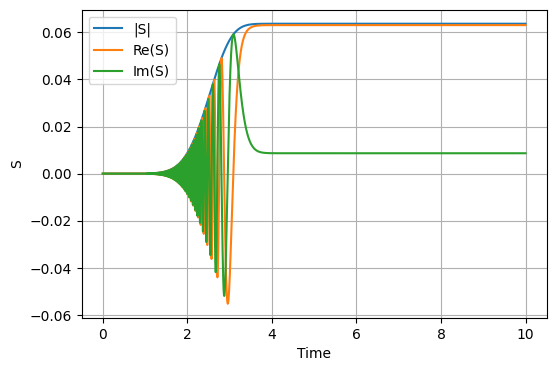

In [ ]:
optimal_a_factor = a_factor_vals[np.argmax(prob_s_vals)]
time, S, prob_s, prob_g, prob_e = three_level_simulation(optimal_a_factor, C, gamma, Delta, T, g_se, g_ge, alpha_in)
plot_probs(time, prob_g, prob_e, prob_s, S)

Now, optimize over all parameters.

In [ ]:
a_factor_vals =  np.linspace(0.01, 5, 50)
C_vals = np.linspace(0, 500, 100)
gamma_vals = np.linspace(0, 10, 50)
Delta_vals = np.linspace(0, 100, 100)
T, g_se, g_ge = 10, 1, 1

def objective_optuna(trial):
    a_factor = trial.suggest_float("a_factor", min(a_factor_vals), max(a_factor_vals))
    C = trial.suggest_float("C", min(C_vals), max(C_vals))
    gamma = trial.suggest_float("gamma", min(gamma_vals), max(gamma_vals))
    Delta = trial.suggest_float("Delta", min(Delta_vals), max(Delta_vals))

    time, S, prob_s, prob_g, prob_e = three_level_simulation(a_factor, C, gamma, Delta, T, g_se, g_ge, alpha_in)
    return prob_s[-1]

study = optuna.create_study(direction="maximize")
study.optimize(objective_optuna, n_trials=100) # n_jobs=-1
print(study.best_params)
print(study.best_value)

[I 2026-03-18 11:24:42,120] A new study created in memory with name: no-name-20103193-ef80-4230-8dbd-110e278e18af
C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\optuna\study\_tell.py:65: ComplexWarning: Casting complex values to real discards the imaginary part
  float(v)
C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\optuna\study\_tell.py:69: ComplexWarning: Casting complex values to real discards the imaginary part
  if math.isnan(v):
C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\optuna\study\_tell.py:166: ComplexWarning: Casting complex values to real discards the imaginary part
  values = [float(value) for value in values]
[I 2026-03-18 11:24:43,934] Trial 0 finished with value: 0.00019900486160897405 and para

{'a_factor': 2.7013712212265957, 'C': 355.7769052822112, 'gamma': 1.0859303806904967, 'Delta': 10.097521640846463}
0.007212499835162323


In [28]:
plot_contour(study, params=["a_factor", "c"])

In [ ]:
plot_optimization_history(study).show()

In [ ]:
plot_parallel_coordinate(study).show()

In [ ]:
plot_param_importances(study).show()

C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


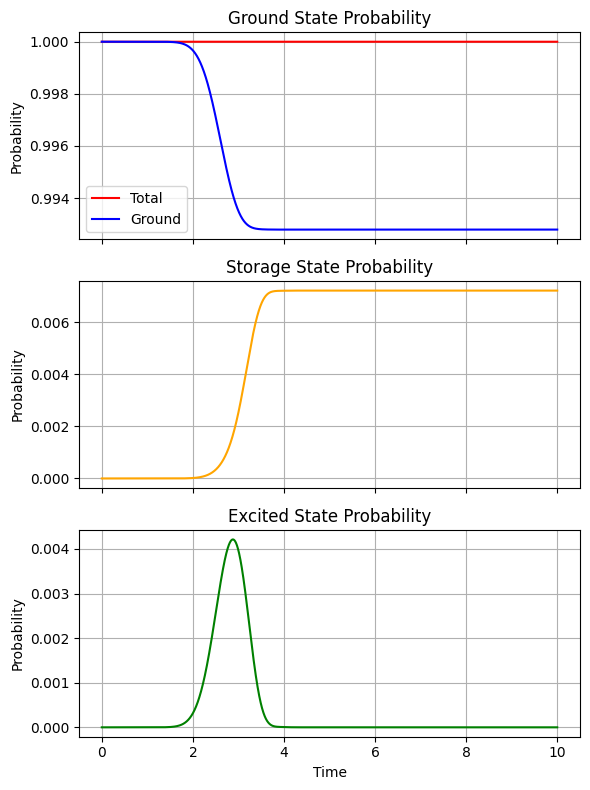

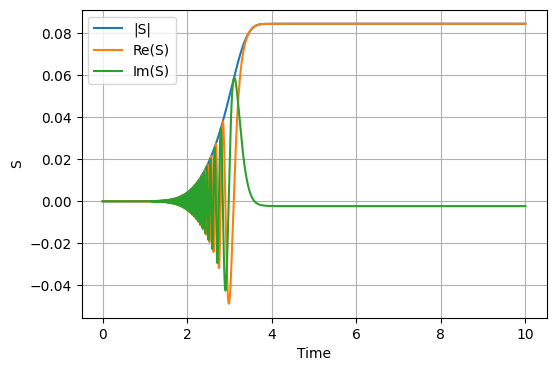

(0.007212499835162323-1.2903853534969102e-19j)


In [17]:
time, S, prob_s, prob_g, prob_e = three_level_simulation(study.best_params['a_factor'], study.best_params['C'], 
                                                         study.best_params['gamma'], study.best_params['Delta'], T, g_se, g_ge, alpha_in)
plot_probs(time, prob_g, prob_e, prob_s, S)
print(prob_s[-1])

## Now, generalize $\beta$.

$$\beta(t) = -(x-zi)\cdot a_{factor} \cdot b \cdot exp(\frac{i\Delta h(t, T)}{c})$$

- $a = -(x-zi)\cdot a_{factor}$
- Modify x, z, c, a_factor

In [19]:
def three_level_simulation_generalized(a_factor, x, z, c, C, gamma, Delta, T, g_se, g_ge, alpha_in_func):
    N = 5000  # number of time steps
    time = np.linspace(0, T, N)
    alpha_in = alpha_in_func  
    alpha = alpha_in(time)
    
    # Prefactors
    a = -a_factor*(x-1j*z)
    
    # Compute b
    b = [0]
    for i in range(1, len(time)):
        integral_val = integrate.simps(abs(alpha[0:i])**2, time[0:i])
        if integral_val == 0:
            b.append(0)
        else:
            b.append(alpha[i] / np.sqrt(integral_val))
    b = np.array(b)
    
    def get_h(beta_vals, idx, time):
        h_val = integrate.simps(np.abs(beta_vals[idx:])**2, time[idx:])
        return h_val
    
    beta_vals = np.array([0])
    for idx in range(len(time)-1):
        h = get_h(a*b, idx, time)
        beta_vals = np.append(beta_vals, a*b[idx]*np.exp(1j*Delta*h/c))
    
    def beta(t):
        if t == time[0]: return 0
        else: return np.interp(t, time, beta_vals)
    
    # Hamiltonian
    H_signal = sigma_ge + sigma_eg
    H_coupling = sigma_se
    H_coupling_dag = sigma_es
    H_detuning = sigma_ee
    
    def H_detuning_coeff(t, args):
        return Delta
    
    def H_signal_coeff(t, args):
        return g_ge * alpha_in(t)
    
    def H_coupling_coeff(t, args):
        return g_se * beta(t)
    
    def H_coupling_dag_coeff(t, args):
        return g_se * np.conjugate(beta(t))
    
    H = [[H_detuning, H_detuning_coeff], [H_signal, H_signal_coeff], [H_coupling, H_coupling_coeff], [H_coupling_dag, H_coupling_dag_coeff]]
    
    # Dissipation
    def col_coeff_eg(t, args):
        return -np.conjugate(g_ge)
    c_op_list = [[sigma_eg, col_coeff_eg], [sigma_eg, -1/C]]
    
    # Simulate
    psi0 = ground
    result = mesolve(H, psi0, time, c_op_list)
    
    # Extract results
    prob_g = []
    prob_s = []
    prob_e = []
    S = []
    for state in result.states:
        p_g, p_s, p_e = state[0][0], state[1][1], state[2][2]
        prob_g.append(p_g)
        prob_s.append(p_s)
        prob_e.append(p_e)
        S.append(expect(sigma_gs, state))
    
    return time, np.array(S), np.array(prob_s), np.array(prob_g), np.array(prob_e)

$$\beta(t) = -(x-zi)\cdot a_{factor} \cdot b \cdot exp(\frac{i\Delta h(t, T)}{c})$$
- $a = -(x-zi)\cdot a_{factor}$
- Modify x, z, c, a_factor

In [20]:
# Starting point for -(x-zi)
C = 200
gamma = 1
Delta = 100
T = 10
g_se = 1
g_ge = 1
a_factor = 1

print('Starting point for (x-zi)*a_factor:', (gamma*(1/C+1) - 1j*Delta) / np.sqrt(2*gamma*(1/C+1)))
print('Starting point for c: ', gamma**2*(1/C+1)**2 + Delta**2)

Starting point for (x-zi)*a_factor: (0.7088723439378912-70.53456158585983j)
Starting point for c:  10001.010025


In [22]:
x_vals = np.linspace(0, 10, 100)
z_vals = np.linspace(10, 100, 100)
c_vals = np.linspace(8000, 50000, 1000)
a_factor_vals =  np.linspace(0.01, 5, 10)

def objective_optuna(trial):
    a_factor = trial.suggest_float("a_factor", min(a_factor_vals), max(a_factor_vals))
    x = trial.suggest_float("x", min(x_vals), max(x_vals))
    z = trial.suggest_float("z", min(z_vals), max(z_vals))
    c = trial.suggest_float("c", min(c_vals), max(c_vals))
    time, S, prob_s, prob_g, prob_e = three_level_simulation_generalized(a_factor, x, z, c, C, gamma, Delta, T, g_se, g_ge, alpha_in)
    return prob_s[-1]

study = optuna.create_study(direction="maximize")
study.optimize(objective_optuna, n_trials=100) # n_jobs=-1

print(study.best_params)
print(study.best_value)

[I 2026-03-18 11:44:57,715] A new study created in memory with name: no-name-6de39e2a-00b8-4eed-8980-3063099466bd
[I 2026-03-18 11:45:00,874] Trial 0 finished with value: 8.781378335425112e-07 and parameters: {'a_factor': 2.517861201710288, 'x': 7.870316298523332, 'z': 55.915310854901925, 'c': 39635.68235163917}. Best is trial 0 with value: 8.781378335425112e-07.
[I 2026-03-18 11:45:09,986] Trial 1 finished with value: 0.00025883965998268284 and parameters: {'a_factor': 2.7581632885049063, 'x': 6.787648503810395, 'z': 95.44837427586972, 'c': 12839.917469021188}. Best is trial 1 with value: 0.00025883965998268284.
[I 2026-03-18 11:45:17,621] Trial 2 finished with value: 3.104922927005266e-06 and parameters: {'a_factor': 3.7192398899331685, 'x': 1.2617509185285458, 'z': 32.35946912806827, 'c': 19689.851913866874}. Best is trial 1 with value: 0.00025883965998268284.
[I 2026-03-18 11:45:26,771] Trial 3 finished with value: 5.485457723496703e-05 and parameters: {'a_factor': 3.48901143702693

{'a_factor': 2.7378265016581165, 'x': 5.227048049457175, 'z': 23.857622834268057, 'c': 10266.55093308101}
0.004687528777057751


## Notes on efficiency:

### Using for loops

In [ ]:
a_factor_vals =  np.linspace(0.01, 5, 10)
C_vals =  np.linspace(0.01, 5, 10)
prob_s_vals = np.zeros((len(C_vals), len(a_factor_vals)))

for i in tqdm(range(len(C_vals))):
    for j in range(len(a_factor_vals)):
        C, a_factor = C_vals[i], a_factor_vals[j]
        time, S, prob_s, prob_g, prob_e = three_level_simulation(a_factor, C, gamma, Delta, T, g_se, g_ge, alpha_in)
        prob_s_vals[i, j] = abs(prob_s[-1])

100%|██████████| 10/10 [05:14<00:00, 31.47s/it]


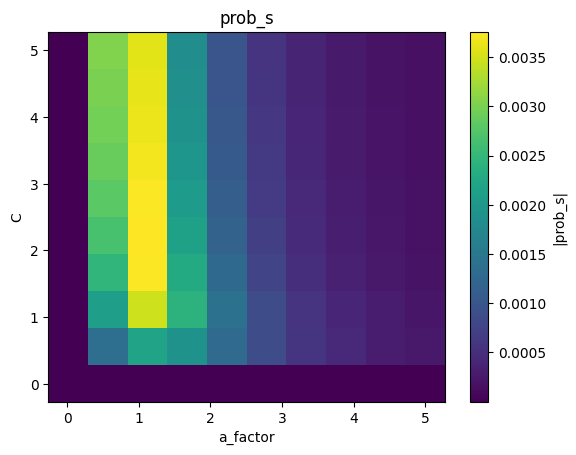

In [ ]:
plt.figure()
plt.pcolormesh(a_factor_vals, C_vals, prob_s_vals, shading='auto', cmap='viridis')
plt.colorbar(label='|prob_s|')
plt.xlabel('a_factor')
plt.ylabel('C')
plt.title('prob_s')
plt.show()

### Using Optuna
Performs parallelization and Bayesian optimization. Other options: random sampling.

In [ ]:
a_factor_vals =  np.linspace(0.01, 50, 50)
C_vals =  np.linspace(1, 500, 50)

def objective_optuna(trial):
    a_factor = trial.suggest_float("a_factor", min(a_factor_vals), max(a_factor_vals))
    C = trial.suggest_float("c", min(C_vals), max(C_vals))
    time, S, prob_s, prob_g, prob_e = three_level_simulation(a_factor, C, gamma, Delta, T, g_se, g_ge, alpha_in)
    return prob_s[-1]

study = optuna.create_study(direction="maximize")
study.optimize(objective_optuna, n_trials=100) # n_jobs=-1

print(study.best_params)
print(study.best_value)

[I 2026-03-18 10:55:18,832] A new study created in memory with name: no-name-aadf53b3-fdc3-45f0-8e73-b6b44f5fb921
C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\optuna\study\_tell.py:65: ComplexWarning: Casting complex values to real discards the imaginary part
  float(v)
C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\optuna\study\_tell.py:69: ComplexWarning: Casting complex values to real discards the imaginary part
  if math.isnan(v):
C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\optuna\study\_tell.py:166: ComplexWarning: Casting complex values to real discards the imaginary part
  values = [float(value) for value in values]
[I 2026-03-18 10:55:22,819] Trial 0 finished with value: -5.6353056794579586e-06 and par

{'a_factor': 0.7563775295541678, 'c': 456.9328191205041}
0.004112753491236003


C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


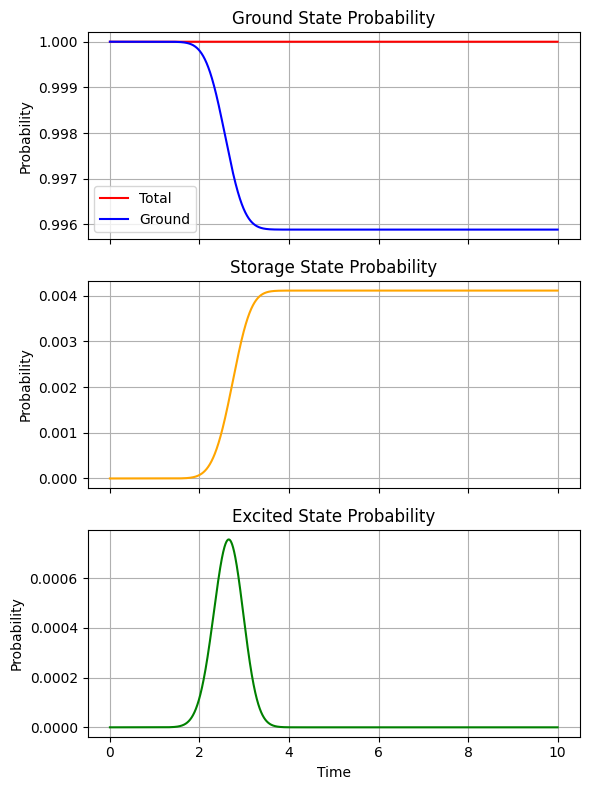

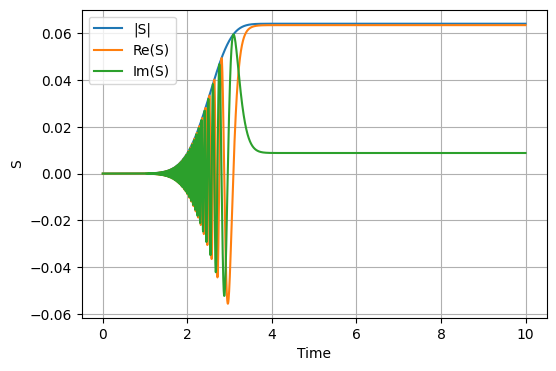

(0.004112753491236003-2.2323967718452215e-18j)


In [ ]:
time, S, prob_s, prob_g, prob_e = three_level_simulation(study.best_params['a_factor'], study.best_params['c'], gamma, Delta, T, g_se, g_ge, alpha_in)
plot_probs(time, prob_g, prob_e, prob_s, S)
print(prob_s[-1])